In [1]:
from pathlib import Path
from collections import Counter
import pandas as pd

# Set How2Sign dataset path
dataset_root = (
    Path.home()
    / "OneDrive"
    / "Documents"
    / "NeuraSign_Datasets"
)

how2sign_folder = dataset_root / "How2sign"

print("How2Sign folder exists:", how2sign_folder.exists())
print("How2Sign folder:", how2sign_folder)

# Find all files recursively
how2sign_files = [
    file
    for file in how2sign_folder.rglob("*")
    if file.is_file()
]

print("\nTotal files found:", len(how2sign_files))

# Count file extensions
extension_counts = Counter(
    file.suffix.lower()
    for file in how2sign_files
)

print("\nFile types:")

for extension, count in sorted(
    extension_counts.items(),
    key=lambda item: item[1],
    reverse=True
):
    print(extension or "No extension", ":", count)

# Display largest files
file_records = []

for file in how2sign_files:

    file_records.append({
        "file_name": file.name,
        "extension": file.suffix.lower(),
        "size_mb": round(
            file.stat().st_size / (1024 * 1024),
            2
        ),
        "full_path": str(file)
    })

files_df = pd.DataFrame(file_records)

if not files_df.empty:

    print("\nLargest files:")
    
    display(
        files_df.sort_values(
            by="size_mb",
            ascending=False
        ).head(30)
    )

How2Sign folder exists: True
How2Sign folder: C:\Users\HP\OneDrive\Documents\NeuraSign_Datasets\How2sign

Total files found: 3

File types:
.csv : 3

Largest files:


,file_name,extension,size_mb,full_path
1,how2sign_realigned_train.csv,.csv,5.35,C:\Users\HP\OneDrive\Documents\NeuraSign_Datas...
0,how2sign_realigned_test.csv,.csv,0.40,C:\Users\HP\OneDrive\Documents\NeuraSign_Datas...
2,how2sign_realigned_val.csv,.csv,0.30,C:\Users\HP\OneDrive\Documents\NeuraSign_Datas...


In [2]:
import pandas as pd

# Locate split files
train_file = (
    how2sign_folder
    / "how2sign_realigned_train.csv"
)

val_file = (
    how2sign_folder
    / "how2sign_realigned_val.csv"
)

test_file = (
    how2sign_folder
    / "how2sign_realigned_test.csv"
)

# Load official splits
train_df = pd.read_csv(train_file)
val_df = pd.read_csv(val_file)
test_df = pd.read_csv(test_file)

print("Training shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nColumn names:")
print(train_df.columns.tolist())

print("\nData types:")
display(
    train_df.dtypes.to_frame(
        name="data_type"
    )
)

print("\nTraining sample:")
display(train_df.head())

print("\nMissing values in training data:")
display(
    train_df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame(name="missing_count")
)

ParserError: Error tokenizing data. C error: Expected 1 fields in line 3, saw 3


In [3]:

from pathlib import Path
import pandas as pd

# Set file paths
train_file = (
    how2sign_folder
    / "how2sign_realigned_train.csv"
)

val_file = (
    how2sign_folder
    / "how2sign_realigned_val.csv"
)

test_file = (
    how2sign_folder
    / "how2sign_realigned_test.csv"
)

# Load tab-separated How2Sign files
train_df = pd.read_csv(
    train_file,
    sep="\t",
    encoding="utf-8",
    engine="python"
)

val_df = pd.read_csv(
    val_file,
    sep="\t",
    encoding="utf-8",
    engine="python"
)

test_df = pd.read_csv(
    test_file,
    sep="\t",
    encoding="utf-8",
    engine="python"
)

print("Training shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nColumn names:")
print(train_df.columns.tolist())

print("\nData types:")
display(
    train_df.dtypes.to_frame(
        name="data_type"
    )
)

print("\nTraining sample:")
display(train_df.head())

print("\nMissing values:")
display(
    train_df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame(name="missing_count")
)

Training shape: (31165, 7)
Validation shape: (1741, 7)
Test shape: (2357, 7)

Column names:
['VIDEO_ID', 'VIDEO_NAME', 'SENTENCE_ID', 'SENTENCE_NAME', 'START_REALIGNED', 'END_REALIGNED', 'SENTENCE']

Data types:


,data_type
VIDEO_ID,str
VIDEO_NAME,str
SENTENCE_ID,str
SENTENCE_NAME,str
START_REALIGNED,float64
END_REALIGNED,float64
SENTENCE,str



Training sample:


,VIDEO_ID,VIDEO_NAME,SENTENCE_ID,SENTENCE_NAME,START_REALIGNED,END_REALIGNED,SENTENCE
0,--7E2sU6zP4,--7E2sU6zP4-5-rgb_front,--7E2sU6zP4_10,--7E2sU6zP4_10-5-rgb_front,129.06,142.48,And I call them decorative elements because ba...
1,--7E2sU6zP4,--7E2sU6zP4-5-rgb_front,--7E2sU6zP4_11,--7E2sU6zP4_11-5-rgb_front,142.49,169.40,So they don't really have much of a symbolic m...
2,--7E2sU6zP4,--7E2sU6zP4-5-rgb_front,--7E2sU6zP4_12,--7E2sU6zP4_12-5-rgb_front,169.45,182.57,"Now this is very, this is actually an insert o..."
3,--7E2sU6zP4,--7E2sU6zP4-5-rgb_front,--7E2sU6zP4_13,--7E2sU6zP4_13-5-rgb_front,183.12,189.01,"This is all the you know, take off on the idea..."
4,--7E2sU6zP4,--7E2sU6zP4-5-rgb_front,--7E2sU6zP4_5,--7E2sU6zP4_5-5-rgb_front,55.95,65.19,It's almost has a feathery like posture to it.



Missing values:


,missing_count
VIDEO_ID,0
VIDEO_NAME,0
SENTENCE_ID,0
SENTENCE_NAME,0
START_REALIGNED,0
END_REALIGNED,0
SENTENCE,0


In [4]:
# Add official split names
train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

# Combine only for inspection
all_df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

# Calculate signing duration
all_df["duration_seconds"] = (
    all_df["END_REALIGNED"]
    - all_df["START_REALIGNED"]
)

print("Total records:", len(all_df))
print("Total columns:", len(all_df.columns))

print("\nMissing values:")
display(
    all_df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame(name="missing_count")
)

print(
    "\nExact duplicate rows:",
    all_df.duplicated().sum()
)

print(
    "Duplicate sentence IDs:",
    all_df["SENTENCE_ID"].duplicated().sum()
)

print(
    "Duplicate sentence text:",
    all_df["SENTENCE"].duplicated().sum()
)

print(
    "\nInvalid durations:",
    (all_df["duration_seconds"] <= 0).sum()
)

print("\nDuration summary:")
display(
    all_df["duration_seconds"]
    .describe()
    .to_frame(name="duration_seconds")
)

print("\nOfficial split distribution:")
display(
    all_df["split"]
    .value_counts()
    .rename_axis("split")
    .reset_index(name="record_count")
)

Total records: 35263
Total columns: 9

Missing values:


,missing_count
VIDEO_ID,0
VIDEO_NAME,0
SENTENCE_ID,0
SENTENCE_NAME,0
START_REALIGNED,0
END_REALIGNED,0
SENTENCE,0
split,0
duration_seconds,0



Exact duplicate rows: 0
Duplicate sentence IDs: 825
Duplicate sentence text: 1780

Invalid durations: 0

Duration summary:


,duration_seconds
count,35263.000000
mean,6.842518
std,6.225411
min,0.010000
25%,2.970000
50%,5.280000
75%,8.820000
max,143.030000



Official split distribution:


,split,record_count
0,train,31165
1,test,2357
2,val,1741


In [5]:
import re
import numpy as np
import pandas as pd

def clean_how2sign_split(dataframe):

    cleaned_df = dataframe.copy()

    # Remove spaces from column names
    cleaned_df.columns = (
        cleaned_df.columns
        .str.strip()
    )

    # Convert required columns to correct types
    cleaned_df["START_REALIGNED"] = pd.to_numeric(
        cleaned_df["START_REALIGNED"],
        errors="coerce"
    )

    cleaned_df["END_REALIGNED"] = pd.to_numeric(
        cleaned_df["END_REALIGNED"],
        errors="coerce"
    )

    # Remove rows with missing essential values
    cleaned_df = cleaned_df.dropna(
        subset=[
            "VIDEO_ID",
            "SENTENCE_ID",
            "SENTENCE",
            "START_REALIGNED",
            "END_REALIGNED"
        ]
    ).copy()

    # Clean ID and sentence columns
    cleaned_df["VIDEO_ID"] = (
        cleaned_df["VIDEO_ID"]
        .astype(str)
        .str.strip()
    )

    cleaned_df["SENTENCE_ID"] = (
        cleaned_df["SENTENCE_ID"]
        .astype(str)
        .str.strip()
    )

    cleaned_df["SENTENCE"] = (
        cleaned_df["SENTENCE"]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(
            r"\s+",
            " ",
            regex=True
        )
    )

    # Calculate actual signing duration
    cleaned_df["duration_seconds"] = (
        cleaned_df["END_REALIGNED"]
        - cleaned_df["START_REALIGNED"]
    )

    # Keep only valid sentences and durations
    cleaned_df = cleaned_df[
        (cleaned_df["SENTENCE"].str.len() > 0)
        & (cleaned_df["duration_seconds"] > 0)
    ].copy()

    # Remove duplicate sentence records
    cleaned_df = cleaned_df.drop_duplicates(
        subset=["SENTENCE_ID"],
        keep="first"
    )

    return cleaned_df.reset_index(drop=True)


# Clean official splits separately
train_clean = clean_how2sign_split(train_df)
val_clean = clean_how2sign_split(val_df)
test_clean = clean_how2sign_split(test_df)

print("Clean training records:", len(train_clean))
print("Clean validation records:", len(val_clean))
print("Clean test records:", len(test_clean))

print("\nRemoved from training:")
print(len(train_df) - len(train_clean))

print("Removed from validation:")
print(len(val_df) - len(val_clean))

print("Removed from testing:")
print(len(test_df) - len(test_clean))

print("\nMissing values after cleaning:")
print(
    "Train:",
    train_clean[
        [
            "SENTENCE",
            "START_REALIGNED",
            "END_REALIGNED",
            "duration_seconds"
        ]
    ].isna().sum().sum()
)

print(
    "Validation:",
    val_clean[
        [
            "SENTENCE",
            "START_REALIGNED",
            "END_REALIGNED",
            "duration_seconds"
        ]
    ].isna().sum().sum()
)

print(
    "Test:",
    test_clean[
        [
            "SENTENCE",
            "START_REALIGNED",
            "END_REALIGNED",
            "duration_seconds"
        ]
    ].isna().sum().sum()
)

Clean training records: 30932
Clean validation records: 1529
Clean test records: 1977

Removed from training:
233
Removed from validation:
212
Removed from testing:
380

Missing values after cleaning:
Train: 0
Validation: 0
Test: 0


In [6]:
import string

def add_sentence_features(dataframe):

    feature_df = dataframe.copy()

    # Split sentences into words
    words = feature_df["SENTENCE"].str.split()

    # Create text-based numerical features
    feature_df["word_count"] = words.str.len()

    feature_df["character_count"] = (
        feature_df["SENTENCE"]
        .str.len()
    )

    feature_df["average_word_length"] = (
        words.apply(
            lambda word_list: (
                np.mean([
                    len(word)
                    for word in word_list
                ])
                if word_list
                else 0
            )
        )
    )

    feature_df["unique_word_ratio"] = (
        words.apply(
            lambda word_list: (
                len(set(word_list)) / len(word_list)
                if word_list
                else 0
            )
        )
    )

    feature_df["punctuation_count"] = (
        feature_df["SENTENCE"]
        .apply(
            lambda text: sum(
                character in string.punctuation
                for character in text
            )
        )
    )

    feature_df["question_mark_count"] = (
        feature_df["SENTENCE"]
        .str.count(r"\?")
    )

    feature_df["digit_count"] = (
        feature_df["SENTENCE"]
        .str.count(r"\d")
    )

    return feature_df


# Engineer features separately
train_model_df = add_sentence_features(
    train_clean
)

val_model_df = add_sentence_features(
    val_clean
)

test_model_df = add_sentence_features(
    test_clean
)

# Learn target boundaries only from training durations
short_boundary = train_model_df[
    "duration_seconds"
].quantile(0.33)

long_boundary = train_model_df[
    "duration_seconds"
].quantile(0.66)

print(
    "Short duration boundary:",
    round(short_boundary, 2),
    "seconds"
)

print(
    "Long duration boundary:",
    round(long_boundary, 2),
    "seconds"
)


def create_duration_class(duration):

    if duration <= short_boundary:
        return "Short"

    elif duration <= long_boundary:
        return "Medium"

    else:
        return "Long"


# Apply the same training boundaries to every split
train_model_df["target_class"] = (
    train_model_df["duration_seconds"]
    .apply(create_duration_class)
)

val_model_df["target_class"] = (
    val_model_df["duration_seconds"]
    .apply(create_duration_class)
)

test_model_df["target_class"] = (
    test_model_df["duration_seconds"]
    .apply(create_duration_class)
)

print("\nTraining target distribution:")
display(
    train_model_df["target_class"]
    .value_counts()
    .rename_axis("target_class")
    .reset_index(name="sample_count")
)

print("\nValidation target distribution:")
display(
    val_model_df["target_class"]
    .value_counts()
    .rename_axis("target_class")
    .reset_index(name="sample_count")
)

print("\nTest target distribution:")
display(
    test_model_df["target_class"]
    .value_counts()
    .rename_axis("target_class")
    .reset_index(name="sample_count")
)

Short duration boundary: 3.67 seconds
Long duration boundary: 7.25 seconds

Training target distribution:


,target_class,sample_count
0,Long,10509
1,Short,10216
2,Medium,10207



Validation target distribution:


,target_class,sample_count
0,Long,561
1,Short,502
2,Medium,466



Test target distribution:


,target_class,sample_count
0,Short,689
1,Long,655
2,Medium,633


In [7]:
from sklearn.impute import SimpleImputer

# Text features used by ID3
feature_columns = [
    "word_count",
    "character_count",
    "average_word_length",
    "unique_word_ratio",
    "punctuation_count",
    "question_mark_count",
    "digit_count"
]

# Separate features and labels
X_train = train_model_df[
    feature_columns
].copy()

y_train = train_model_df[
    "target_class"
].copy()

X_val = val_model_df[
    feature_columns
].copy()

y_val = val_model_df[
    "target_class"
].copy()

X_test = test_model_df[
    feature_columns
].copy()

y_test = test_model_df[
    "target_class"
].copy()

# Learn outlier boundaries only from training data
outlier_features = [
    "word_count",
    "character_count",
    "average_word_length",
    "punctuation_count"
]

outlier_bounds = {}

for feature in outlier_features:

    first_quartile = X_train[
        feature
    ].quantile(0.25)

    third_quartile = X_train[
        feature
    ].quantile(0.75)

    iqr = third_quartile - first_quartile

    lower_bound = (
        first_quartile - 1.5 * iqr
    )

    upper_bound = (
        third_quartile + 1.5 * iqr
    )

    outlier_bounds[feature] = {
        "lower": float(lower_bound),
        "upper": float(upper_bound)
    }


def apply_outlier_bounds(dataframe, bounds):

    processed_df = dataframe.copy()

    for feature, limits in bounds.items():

        processed_df[feature] = (
            processed_df[feature]
            .clip(
                lower=limits["lower"],
                upper=limits["upper"]
            )
        )

    return processed_df


# Apply training boundaries to every split
X_train_clipped = apply_outlier_bounds(
    X_train,
    outlier_bounds
)

X_val_clipped = apply_outlier_bounds(
    X_val,
    outlier_bounds
)

X_test_clipped = apply_outlier_bounds(
    X_test,
    outlier_bounds
)

# Learn median values only from training data
imputer = SimpleImputer(
    strategy="median"
)

X_train_processed = pd.DataFrame(
    imputer.fit_transform(X_train_clipped),
    columns=feature_columns,
    index=X_train.index
)

X_val_processed = pd.DataFrame(
    imputer.transform(X_val_clipped),
    columns=feature_columns,
    index=X_val.index
)

X_test_processed = pd.DataFrame(
    imputer.transform(X_test_clipped),
    columns=feature_columns,
    index=X_test.index
)

print("Training shape:", X_train_processed.shape)
print("Validation shape:", X_val_processed.shape)
print("Test shape:", X_test_processed.shape)

print(
    "\nTraining missing values:",
    X_train_processed.isna().sum().sum()
)

print(
    "Validation missing values:",
    X_val_processed.isna().sum().sum()
)

print(
    "Test missing values:",
    X_test_processed.isna().sum().sum()
)

print("\nFeatures used:")
print(feature_columns)

Training shape: (30932, 7)
Validation shape: (1529, 7)
Test shape: (1977, 7)

Training missing values: 0
Validation missing values: 0
Test missing values: 0

Features used:
['word_count', 'character_count', 'average_word_length', 'unique_word_ratio', 'punctuation_count', 'question_mark_count', 'digit_count']


In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

depth_values = [3, 5, 8, 10, 12, None]
leaf_values = [5, 10, 25, 50]

validation_results = []

best_model = None
best_validation_f1 = -1
best_parameters = None

for depth in depth_values:

    for minimum_leaf in leaf_values:

        model = DecisionTreeClassifier(
            criterion="entropy",
            max_depth=depth,
            min_samples_leaf=minimum_leaf,
            random_state=42
        )

        # Train on official training split
        model.fit(
            X_train_processed,
            y_train
        )

        # Predict official validation split
        validation_predictions = model.predict(
            X_val_processed
        )

        validation_accuracy = accuracy_score(
            y_val,
            validation_predictions
        )

        validation_f1 = f1_score(
            y_val,
            validation_predictions,
            average="macro",
            zero_division=0
        )

        validation_results.append({
            "max_depth": (
                depth if depth is not None else "Full"
            ),
            "min_samples_leaf": minimum_leaf,
            "validation_accuracy": validation_accuracy,
            "validation_macro_f1": validation_f1,
            "tree_depth": model.tree_.max_depth,
            "tree_nodes": model.tree_.node_count
        })

        if validation_f1 > best_validation_f1:

            best_validation_f1 = validation_f1
            best_model = model

            best_parameters = {
                "max_depth": depth,
                "min_samples_leaf": minimum_leaf
            }

# Sort model configurations
validation_results_df = pd.DataFrame(
    validation_results
).sort_values(
    by="validation_macro_f1",
    ascending=False
).reset_index(drop=True)

print("Best parameters:")
print(best_parameters)

print(
    "\nBest validation macro F1:",
    round(best_validation_f1, 4)
)

display(validation_results_df)

Best parameters:
{'max_depth': 10, 'min_samples_leaf': 25}

Best validation macro F1: 0.7207


,max_depth,min_samples_leaf,validation_accuracy,validation_macro_f1,tree_depth,tree_nodes
0,10,25,0.723349,0.720696,10,673
1,12,25,0.721387,0.718580,12,1077
2,Full,25,0.721387,0.718538,20,1607
3,10,10,0.718116,0.716358,10,813
4,10,5,0.717462,0.715852,10,957
5,8,25,0.718116,0.715501,8,319
6,12,50,0.715500,0.713681,12,759
7,Full,50,0.715500,0.713681,18,843
8,8,5,0.717462,0.713072,8,395
9,10,50,0.714846,0.712687,10,595


Final How2Sign ID3 Test Results
--------------------------------
Accuracy: 0.7304
Macro Precision: 0.7257
Macro Recall: 0.727
Macro F1 Score: 0.7261

Classification Report:
              precision    recall  f1-score   support

        Long       0.78      0.77      0.78       655
      Medium       0.60      0.58      0.59       633
       Short       0.79      0.83      0.81       689

    accuracy                           0.73      1977
   macro avg       0.73      0.73      0.73      1977
weighted avg       0.73      0.73      0.73      1977



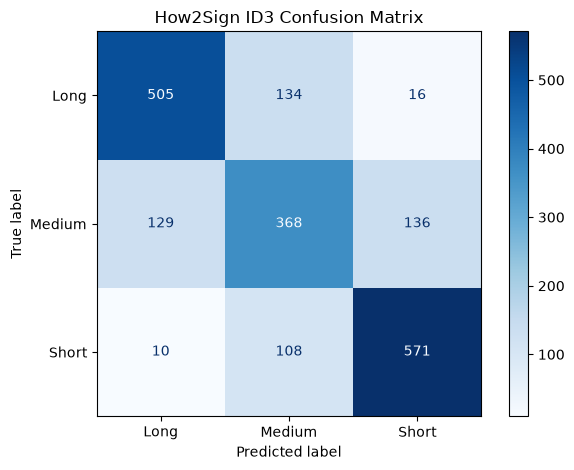

In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# Make final test predictions
test_predictions = best_model.predict(
    X_test_processed
)

# Calculate final metrics
test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_precision = precision_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)

print("Final How2Sign ID3 Test Results")
print("--------------------------------")
print("Accuracy:", round(test_accuracy, 4))
print("Macro Precision:", round(test_precision, 4))
print("Macro Recall:", round(test_recall, 4))
print("Macro F1 Score:", round(test_f1, 4))

# Detailed classification report
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        test_predictions,
        zero_division=0
    )
)

# Create report table for saving later
class_report = classification_report(
    y_test,
    test_predictions,
    output_dict=True,
    zero_division=0
)

class_report_df = (
    pd.DataFrame(class_report)
    .transpose()
)

# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    labels=best_model.classes_,
    display_labels=best_model.classes_,
    cmap="Blues"
)

plt.title(
    "How2Sign ID3 Confusion Matrix"
)

plt.tight_layout()
plt.show()

How2Sign feature importance:


,feature,importance
0,character_count,0.959317
1,average_word_length,0.017726
2,unique_word_ratio,0.010164
3,punctuation_count,0.008114
4,word_count,0.002487
5,digit_count,0.002025
6,question_mark_count,0.000168


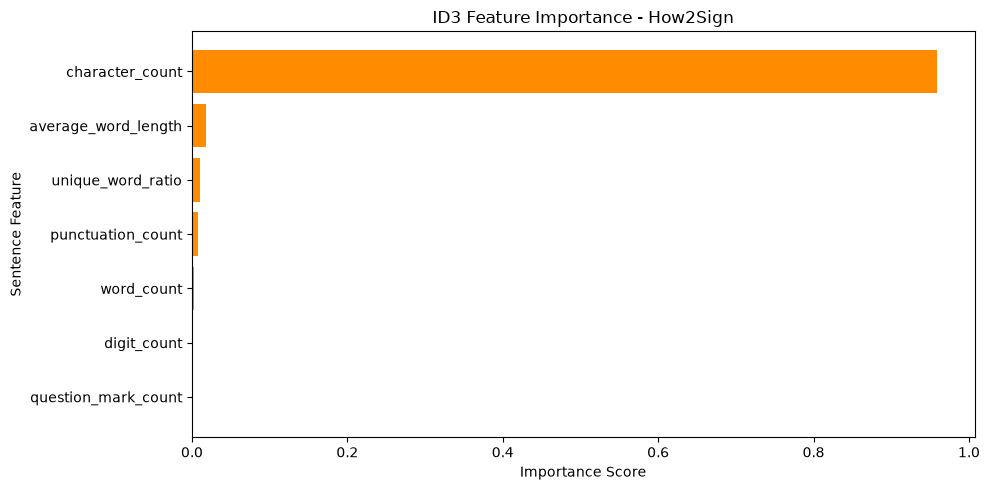

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Create feature importance table
feature_importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": best_model.feature_importances_
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("How2Sign feature importance:")
display(feature_importance_df)

# Plot feature importance
plt.figure(figsize=(10, 5))

plt.barh(
    feature_importance_df["feature"],
    feature_importance_df["importance"],
    color="darkorange"
)

plt.xlabel("Importance Score")
plt.ylabel("Sentence Feature")
plt.title(
    "ID3 Feature Importance - How2Sign"
)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

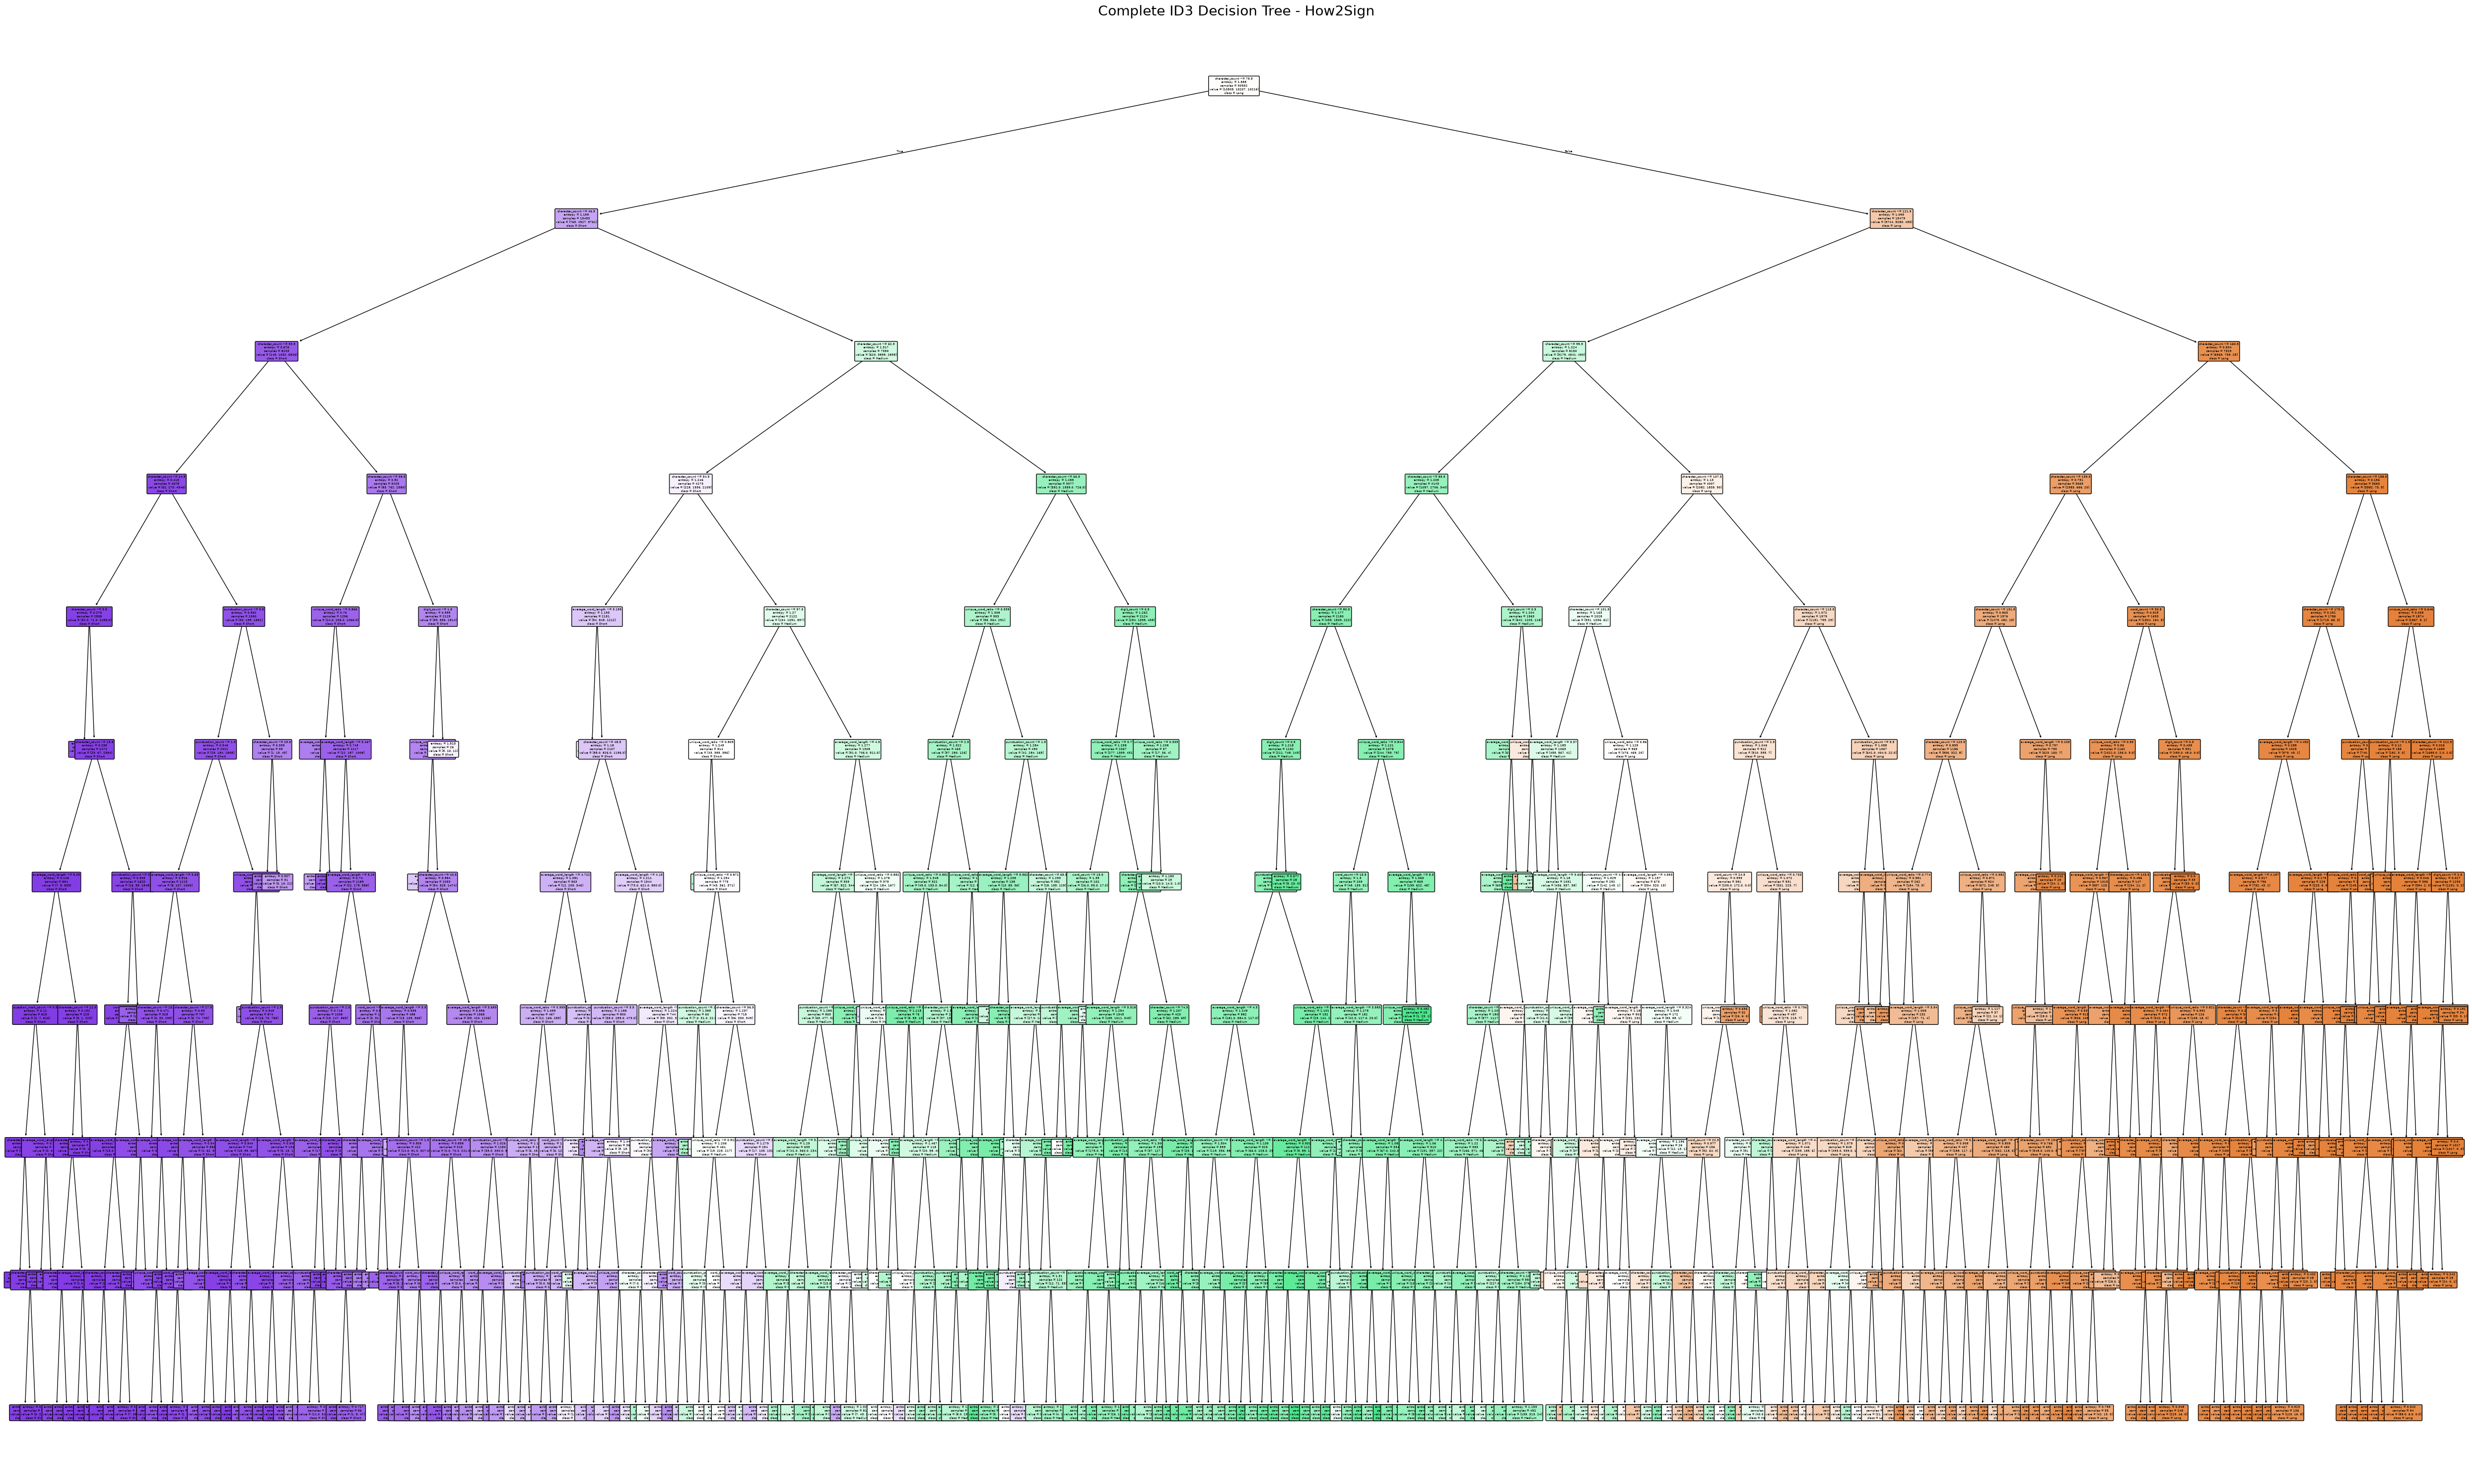

Complete tree image saved:
c:\Users\HP\OneDrive\Documents\NeuraSign\results\how2sign_full_id3_tree.png

Complete tree rules saved:
c:\Users\HP\OneDrive\Documents\NeuraSign\results\how2sign_full_id3_tree.txt

Tree depth: 10
Total tree nodes: 673


In [11]:
from pathlib import Path
from sklearn.tree import plot_tree, export_text
import matplotlib.pyplot as plt

# Set project and results paths
project_path = Path.cwd().parent

results_folder = project_path / "results"
results_folder.mkdir(parents=True, exist_ok=True)

tree_image_path = (
    results_folder
    / "how2sign_full_id3_tree.png"
)

tree_text_path = (
    results_folder
    / "how2sign_full_id3_tree.txt"
)

# Create complete decision tree image
plt.figure(figsize=(50, 30))

plot_tree(
    best_model,
    feature_names=feature_columns,
    class_names=[
        str(class_name)
        for class_name in best_model.classes_
    ],
    filled=True,
    rounded=True,
    fontsize=4
)

plt.title(
    "Complete ID3 Decision Tree - How2Sign",
    fontsize=20
)

plt.tight_layout()

plt.savefig(
    tree_image_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# Export complete tree rules as text
tree_rules = export_text(
    best_model,
    feature_names=feature_columns,
    max_depth=best_model.tree_.max_depth
)

with open(
    tree_text_path,
    "w",
    encoding="utf-8"
) as file:
    file.write(tree_rules)

print("Complete tree image saved:")
print(tree_image_path)

print("\nComplete tree rules saved:")
print(tree_text_path)

print("\nTree depth:", best_model.tree_.max_depth)
print("Total tree nodes:", best_model.tree_.node_count)

In [12]:
import json
import joblib
from pathlib import Path
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create output folders
processed_folder = (
    project_path
    / "data"
    / "processed"
    / "how2sign"
)

models_folder = project_path / "models"
results_folder = project_path / "results"

processed_folder.mkdir(parents=True, exist_ok=True)
models_folder.mkdir(parents=True, exist_ok=True)
results_folder.mkdir(parents=True, exist_ok=True)

# Combine processed official splits
complete_model_df = pd.concat(
    [
        train_model_df,
        val_model_df,
        test_model_df
    ],
    ignore_index=True
)

# Define file paths
processed_data_path = (
    processed_folder
    / "how2sign_model_ready.csv"
)

model_path = (
    models_folder
    / "how2sign_id3_model.joblib"
)

imputer_path = (
    models_folder
    / "how2sign_imputer.joblib"
)

preprocessing_path = (
    models_folder
    / "how2sign_preprocessing_rules.json"
)

validation_results_path = (
    results_folder
    / "how2sign_validation_results.csv"
)

feature_importance_path = (
    results_folder
    / "how2sign_feature_importance.csv"
)

classification_report_path = (
    results_folder
    / "how2sign_classification_report.csv"
)

test_results_path = (
    results_folder
    / "how2sign_test_results.json"
)

confusion_matrix_path = (
    results_folder
    / "how2sign_confusion_matrix.png"
)

# Save processed dataset
complete_model_df.to_csv(
    processed_data_path,
    index=False,
    encoding="utf-8"
)

# Save model and imputer
joblib.dump(best_model, model_path)
joblib.dump(imputer, imputer_path)

# Save preprocessing rules
preprocessing_rules = {
    "short_boundary_seconds": float(short_boundary),
    "long_boundary_seconds": float(long_boundary),
    "outlier_bounds": outlier_bounds,
    "features": feature_columns
}

with open(
    preprocessing_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        preprocessing_rules,
        file,
        indent=4
    )

# Save tabular results
validation_results_df.to_csv(
    validation_results_path,
    index=False
)

feature_importance_df.to_csv(
    feature_importance_path,
    index=False
)

class_report_df.to_csv(
    classification_report_path
)

# Save confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    labels=best_model.classes_,
    display_labels=best_model.classes_,
    cmap="Blues"
)

plt.title("How2Sign ID3 Confusion Matrix")
plt.tight_layout()
plt.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# Save final result summary
final_results = {
    "dataset": "How2Sign Realigned Sentence Metadata",
    "algorithm": "ID3 Decision Tree",
    "criterion": "entropy",
    "prediction_task": (
        "Signing duration classification"
    ),
    "target_classes": [
        "Short",
        "Medium",
        "Long"
    ],
    "short_boundary_seconds": float(short_boundary),
    "long_boundary_seconds": float(long_boundary),
    "total_samples": int(len(complete_model_df)),
    "training_samples": int(len(X_train_processed)),
    "validation_samples": int(len(X_val_processed)),
    "test_samples": int(len(X_test_processed)),
    "best_max_depth": best_parameters["max_depth"],
    "best_min_samples_leaf": best_parameters[
        "min_samples_leaf"
    ],
    "test_accuracy": float(test_accuracy),
    "test_macro_precision": float(test_precision),
    "test_macro_recall": float(test_recall),
    "test_macro_f1": float(test_f1),
    "tree_depth": int(best_model.tree_.max_depth),
    "tree_nodes": int(best_model.tree_.node_count),
    "features": feature_columns
}

with open(
    test_results_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        final_results,
        file,
        indent=4
    )

print("All How2Sign files saved successfully:\n")
print("Processed dataset:", processed_data_path)
print("ID3 model:", model_path)
print("Imputer:", imputer_path)
print("Preprocessing rules:", preprocessing_path)
print("Validation results:", validation_results_path)
print("Feature importance:", feature_importance_path)
print("Classification report:", classification_report_path)
print("Confusion matrix:", confusion_matrix_path)
print("Test results:", test_results_path)

All How2Sign files saved successfully:

Processed dataset: c:\Users\HP\OneDrive\Documents\NeuraSign\data\processed\how2sign\how2sign_model_ready.csv
ID3 model: c:\Users\HP\OneDrive\Documents\NeuraSign\models\how2sign_id3_model.joblib
Imputer: c:\Users\HP\OneDrive\Documents\NeuraSign\models\how2sign_imputer.joblib
Preprocessing rules: c:\Users\HP\OneDrive\Documents\NeuraSign\models\how2sign_preprocessing_rules.json
Validation results: c:\Users\HP\OneDrive\Documents\NeuraSign\results\how2sign_validation_results.csv
Feature importance: c:\Users\HP\OneDrive\Documents\NeuraSign\results\how2sign_feature_importance.csv
Classification report: c:\Users\HP\OneDrive\Documents\NeuraSign\results\how2sign_classification_report.csv
Confusion matrix: c:\Users\HP\OneDrive\Documents\NeuraSign\results\how2sign_confusion_matrix.png
Test results: c:\Users\HP\OneDrive\Documents\NeuraSign\results\how2sign_test_results.json
